In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import h5py

In [54]:
from rc import ESN, ESNConfig

In [55]:

with h5py.File('../data_eigenworm/crawl.mat', 'r') as f:
    tr_refs = f['tr'][1]
    print(f"tr shape: {tr_refs.shape}")
    
    tr_data = []
    for ref in tr_refs.flatten():
        data = f[ref][:]
        tr_data.append(data)
        print(f"Data shape: {data.shape}")


tr shape: (1,)
Data shape: (5, 33600)


In [4]:
def filter_nans(pcs):
    nan_mask = np.isnan(pcs).any(axis=0)
    
    valid_indices = np.where(~nan_mask)[0]
    
    indexes_to_skip = []
    for i in range(1, len(valid_indices)):
        if valid_indices[i] - valid_indices[i-1] > 1:
            indexes_to_skip.append(i)
    
    filtered_pcs = pcs[:, ~nan_mask]
    
    return filtered_pcs, indexes_to_skip
all_pcs = []
all_skip_indices = [] 
current_index = 0

for i in range(len(tr_data)):  
    filtered_pcs, gap_indices = filter_nans(tr_data[i][:5, :])
    
    for idx in gap_indices:
        all_skip_indices.append(idx + current_index)
    
    all_pcs.append(filtered_pcs)
    current_index += filtered_pcs.shape[1]
    
    if i < len(tr_data) - 1:
        all_skip_indices.append(current_index)

all_pcs = np.hstack(all_pcs)

In [5]:
worm_N2_scaled = StandardScaler().fit_transform(all_pcs.T).T

In [6]:
dt = 1/16

In [7]:
config = ESNConfig(
    N=10000,
    input_dim=5,
    spectral_radius=0.1809616855907689,
    alpha=1.5,
    sparsity=0.99,
    input_scaling=1.2665236214415563,
    bias_scaling=0.01,
    seed=None,
    mode='leaky',
    leaky_rate=0.7057809844406092,
)

In [8]:
config

ESNConfig(N=10000, input_dim=5, spectral_radius=0.1809616855907689, alpha=1.5, sparsity=0.99, input_scaling=1.2665236214415563, bias_scaling=0.01, seed=None, weights_generation_strategy='Gaussian', bias_generation_strategy='Uniform', input_generation_strategy='Uniform', self_connections=False, dtype=dtype('float64'), mode='leaky', leaky_rate=0.7057809844406092, beta=0.5, scale=0.1)

In [9]:
worm_N2_scaled_resampled = worm_N2_scaled[:, ::2]

In [10]:
inputdim = 5


In [25]:
esn = ESN(config)
esn.train(worm_N2_scaled[:inputdim, :], washout=2000)


In [41]:
esn_resampled = ESN.load("/Users/iliasoroka/RC/esn_resampled.pkl.npz")

In [45]:
esn_resampled.train(worm_N2_scaled_resampled[:inputdim, :], washout=2000)


In [47]:
warmup_data_resampled = worm_N2_scaled_resampled[:inputdim, :2000]
predictions, states = esn_resampled.predict(warmup_data_resampled, steps=5000)

In [56]:
warmup_data = worm_N2_scaled[:inputdim, 2000:4000]
predictions, states = esn.predict(warmup_data, steps=10000)

KeyboardInterrupt: 

In [27]:
read_data_slice = worm_N2_scaled[:inputdim, 4000:14000]

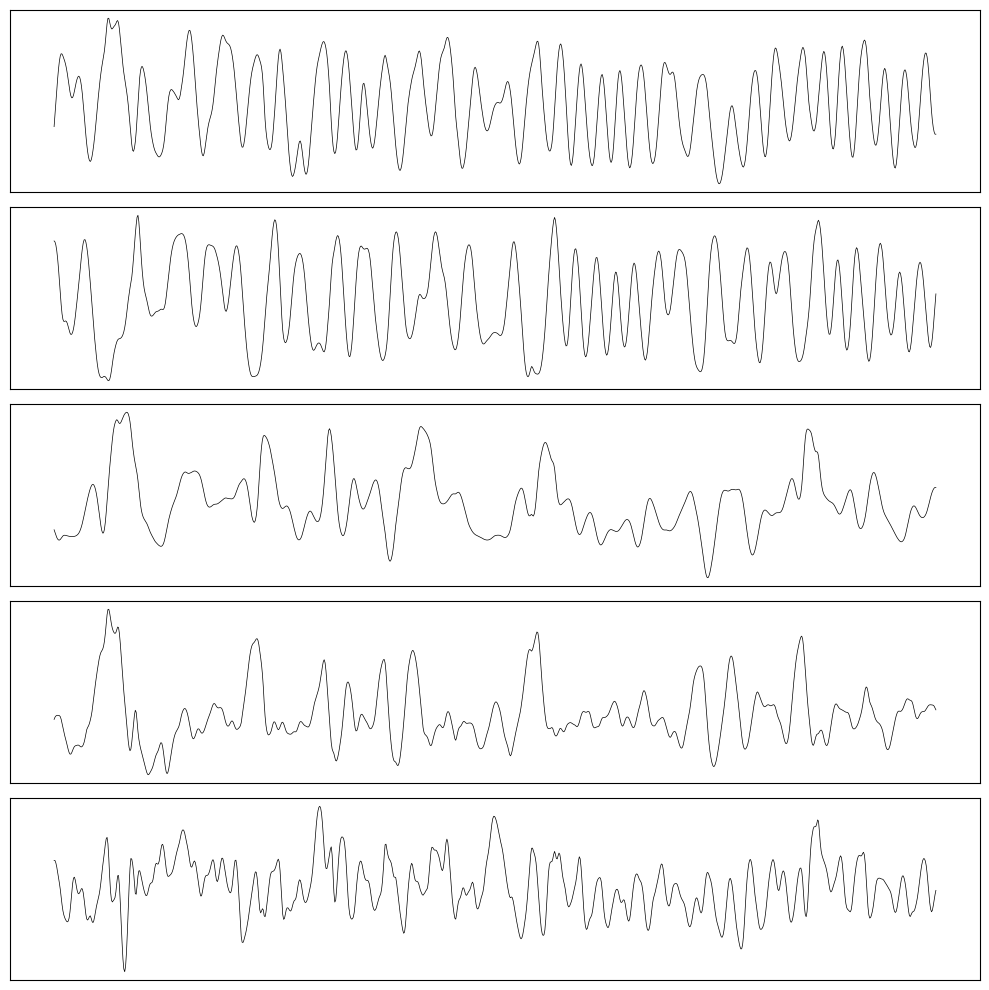

In [28]:
fig, axes = plt.subplots(5, 1, figsize=(10, 10))

for i in range(5):
    axes[i].plot(read_data_slice[i, :1000], linewidth=0.5, color='black')
    # axes[i].set_ylabel(f'Dim {i}')
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('read_data_slice.svg', format='svg', transparent=True)
plt.savefig('read_data_slice.pdf', format='pdf', bbox_inches='tight')
plt.show()


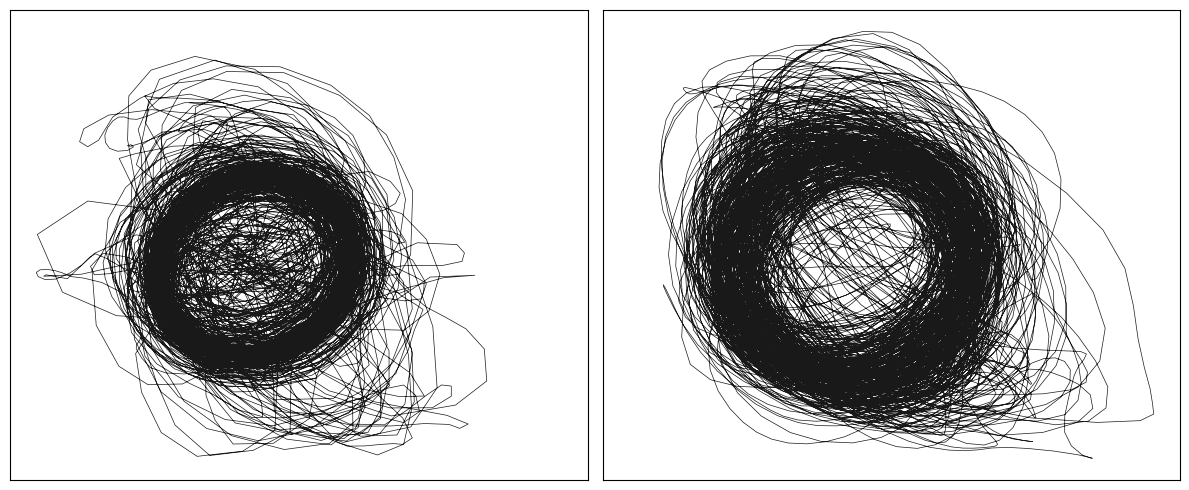

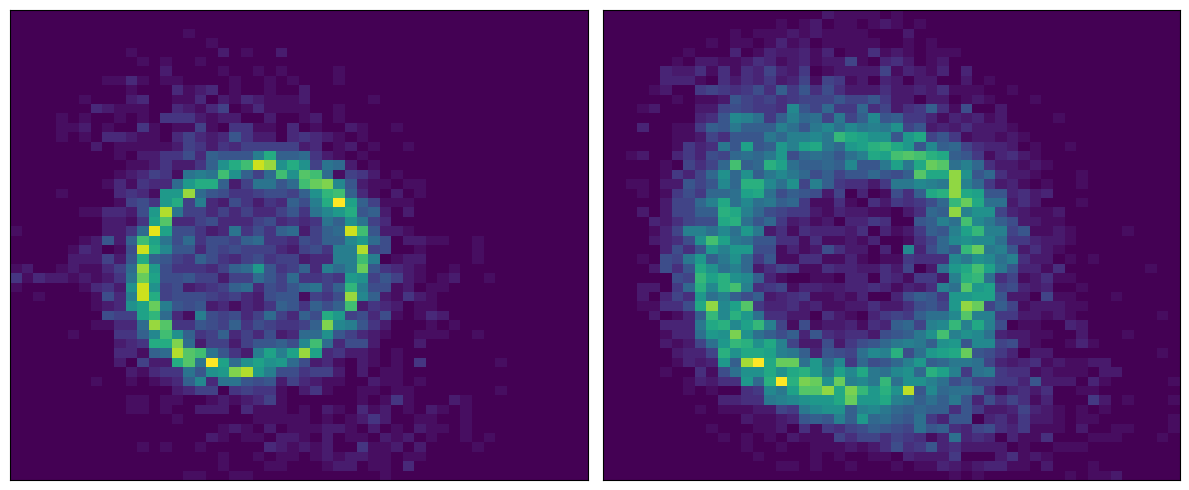

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

x_padding = (x_max - x_min) * 0.05
y_padding = (y_max - y_min) * 0.05

ax1.plot(predictions[0, :], predictions[1, :], 'black', linewidth=0.5, alpha=0.9)

ax1.set_xlim(x_min - x_padding, x_max + x_padding)
ax1.set_ylim(y_min - y_padding, y_max + y_padding)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.plot(read_data_slice[0, :], read_data_slice[1, :], 'black', linewidth=0.5, alpha=0.9)

ax2.set_xlim(x_min - x_padding, x_max + x_padding)
ax2.set_ylim(y_min - y_padding, y_max + y_padding)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('prediction_vs_real.svg', format='svg', transparent=True)
# plt.savefig('prediction_vs_real.pdf', format='pdf', bbox_inches='tight')
plt.show()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x_min = min(predictions[0, :].min(), read_data_slice[0, :].min())
x_max = max(predictions[0, :].max(), read_data_slice[0, :].max())
y_min = min(predictions[1, :].min(), read_data_slice[1, :].min())
y_max = max(predictions[1, :].max(), read_data_slice[1, :].max())

ax1.hist2d(predictions[0, :], predictions[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.set_xticks([])
ax1.set_yticks([])

ax2.hist2d(read_data_slice[0, :], read_data_slice[1, :], bins=50, range=[[x_min, x_max], [y_min, y_max]])
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.set_xticks([])
ax2.set_yticks([])

plt.tight_layout()
# plt.savefig('histogram_prediction.svg', format='svg', transparent=True)
# plt.savefig('histogram_real.svg', format='svg', transparent=True)
plt.show()